# LoCoMo cross-system retrieval

Headline benchmark: direct retrieval on upstream `locomo10.json` (10
conversations, 5,882 turns, 1,536 questions, top-k = 10). Each system is
seeded with the same conversation turns and scored against LoCoMo evidence
IDs. memd is compared against `mem0` and `SuperLocalMemory`.

Data: `evals/notebooks/data/locomo_2026-06-11.json` (summary slice of the
checked-in `evals/benchmarks/locomo/results/` report). Figures are written
to `docs/figures/` for the benchmark writeup.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import matplotlib.pyplot as plt
import numpy as np
from memd_plotting import (apply_house_style, color_for, label_bars,
                            load_json, locomo_systems, figures_dir,
                            LOCOMO_CATEGORY)
apply_house_style()
FIG = figures_dir()
report = load_json('data/locomo_2026-06-11.json')
systems = locomo_systems(report)
order = ['memd', 'mem0', 'superlocalmemory']
systems.sort(key=lambda s: order.index(s['name']) if s['name'] in order else 99)
[(s['display'], round(s['mrr_at_10'], 3)) for s in systems]

[('memd', 0.412), ('mem0', 0.354), ('SuperLocalMemory', 0.369)]

## Figure 1 — retrieval quality (MRR@10 and Hit@k)

Grouped horizontal bars: the single quality summary readers care about.
memd leads on every metric.

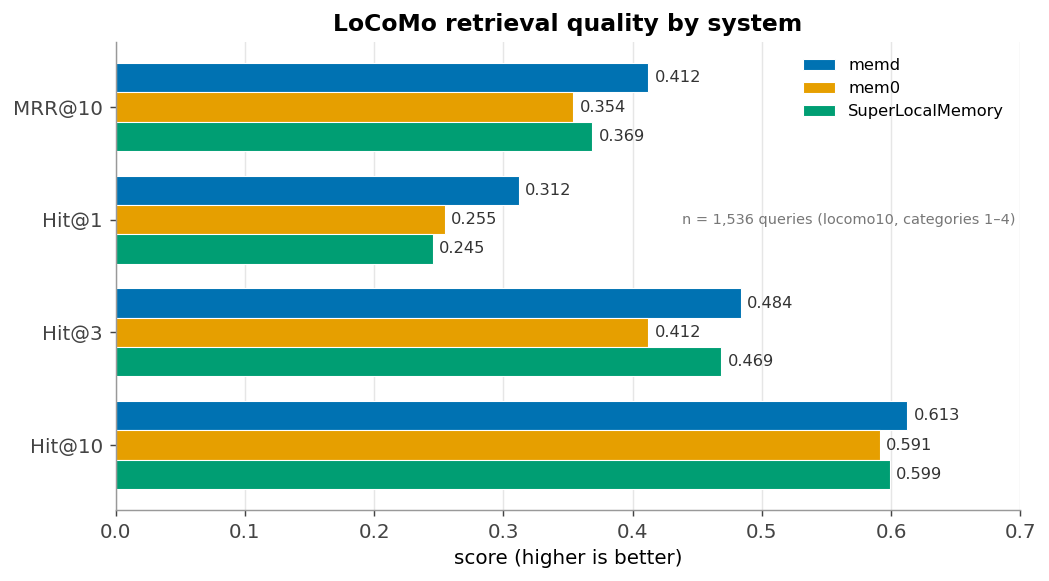

In [2]:
metrics = [('mrr_at_10', 'MRR@10'), ('hit1', 'Hit@1'), ('hit3', 'Hit@3'), ('hit10', 'Hit@10')]
names = [s['display'] for s in systems]
y = np.arange(len(metrics))
h = 0.78 / len(systems)
fig, ax = plt.subplots(figsize=(8.2, 4.6))
for i, s in enumerate(systems):
    vals = [s[k] for k, _ in metrics]
    offset = (i - (len(systems) - 1) / 2) * h
    bars = ax.barh(y + offset, vals, height=h, color=color_for(s['name']),
                   label=s['display'], edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', ha='left', fontsize=9, color='#333333')
ax.set_yticks(y)
ax.set_yticklabels([lbl for _, lbl in metrics])
ax.invert_yaxis()
ax.set_xlim(0, 0.70)
ax.set_xlabel('score (higher is better)')
ax.set_title('LoCoMo retrieval quality by system')
# Anchor the legend in the empty upper-right (MRR@10/Hit@1 rows top out
# near 0.42), clear of the long Hit@10 bars at the bottom.
ax.legend(loc='upper right', ncol=1, fontsize=9, borderaxespad=0.6)
ax.grid(axis='y', visible=False)
ax.text(0.995, 0.62, 'n = 1,536 queries (locomo10, categories 1\u20134)',
        transform=ax.transAxes, ha='right', va='center', fontsize=8, color='#777777')
fig.tight_layout()
fig.savefig(FIG / 'locomo_quality.png')
fig.savefig(FIG / 'locomo_quality.svg')
plt.show()

## Figure 2 — quality vs. search latency

The other axis that matters operationally: memd is both the most accurate
and among the fastest to query. Bubble area is proportional to p95 search
latency; the x-axis is mean search latency (log scale — SuperLocalMemory is
an order of magnitude slower).

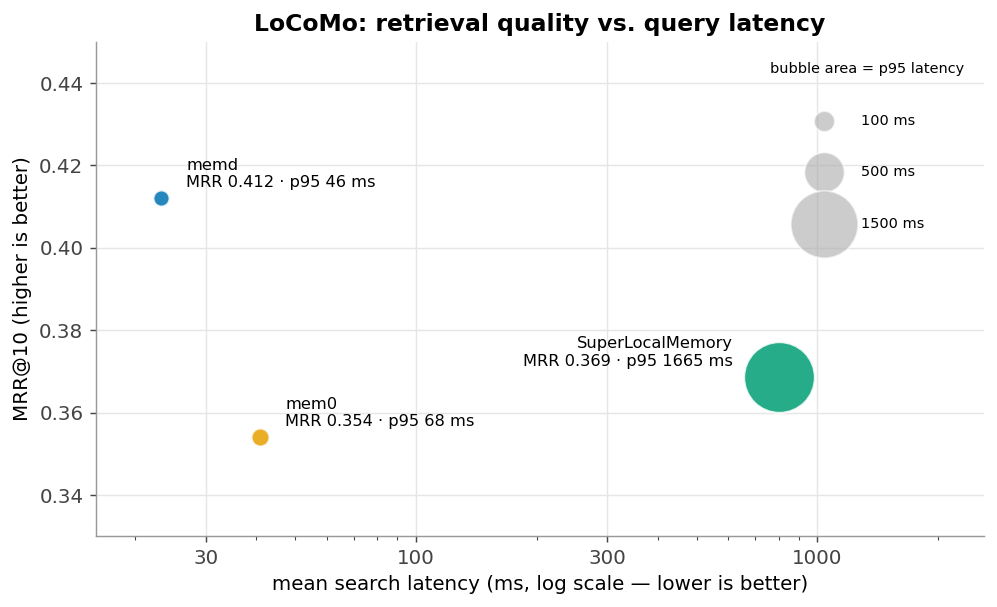

In [3]:
from matplotlib.ticker import FuncFormatter

def bubble_area(p95_ms):
    """Marker size (pts^2, i.e. area) proportional to p95 latency."""
    return max(p95_ms, 1.0) * 0.9 + 40

fig, ax = plt.subplots(figsize=(7.8, 4.8))
# SuperLocalMemory sits at the right edge: annotate it to the LEFT of its
# bubble so the label stays inside the canvas.
label_side = {'superlocalmemory': 'left'}
for s in systems:
    ax.scatter(s['avg_search_ms'], s['mrr_at_10'], s=bubble_area(s['p95_search_ms']),
               color=color_for(s['name']), alpha=0.85, edgecolor='white', linewidth=1.2,
               zorder=3)
    text = f"{s['display']}\nMRR {s['mrr_at_10']:.3f} \u00b7 p95 {s['p95_search_ms']:.0f} ms"
    if label_side.get(s['name']) == 'left':
        ax.annotate(text, (s['avg_search_ms'], s['mrr_at_10']), textcoords='offset points',
                    xytext=(-26, 6), fontsize=9, ha='right')
    else:
        ax.annotate(text, (s['avg_search_ms'], s['mrr_at_10']), textcoords='offset points',
                    xytext=(14, 6), fontsize=9, ha='left')
ax.set_xscale('log')
ax.set_xticks([30, 100, 300, 1000])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
ax.set_xlim(16, 2600)
ax.set_xlabel('mean search latency (ms, log scale \u2014 lower is better)')
ax.set_ylabel('MRR@10 (higher is better)')
ax.set_title('LoCoMo: retrieval quality vs. query latency')
ax.set_ylim(0.33, 0.45)
# Bubble-size key (area encodes p95 latency) in the empty upper-right,
# clear of the SuperLocalMemory bubble and its annotation.
ref = [100, 500, 1500]
handles = [ax.scatter([], [], s=bubble_area(v), color='#AAAAAA', alpha=0.6,
                      edgecolor='white', linewidth=1.0) for v in ref]
ax.legend(handles, [f'{v} ms' for v in ref], title='bubble area = p95 latency',
          loc='upper right', fontsize=8, title_fontsize=8, frameon=False,
          labelspacing=2.6, borderpad=1.0, handletextpad=1.6, borderaxespad=0.4)
fig.tight_layout()
fig.savefig(FIG / 'locomo_quality_latency.png')
fig.savefig(FIG / 'locomo_quality_latency.svg')
plt.show()

## Figure 3 — per-category MRR@10 heatmap

LoCoMo's four question categories stress different memory behaviours.
memd leads all four; its margin is widest on category 2 (temporal).
The outlined cell marks the best system per category.

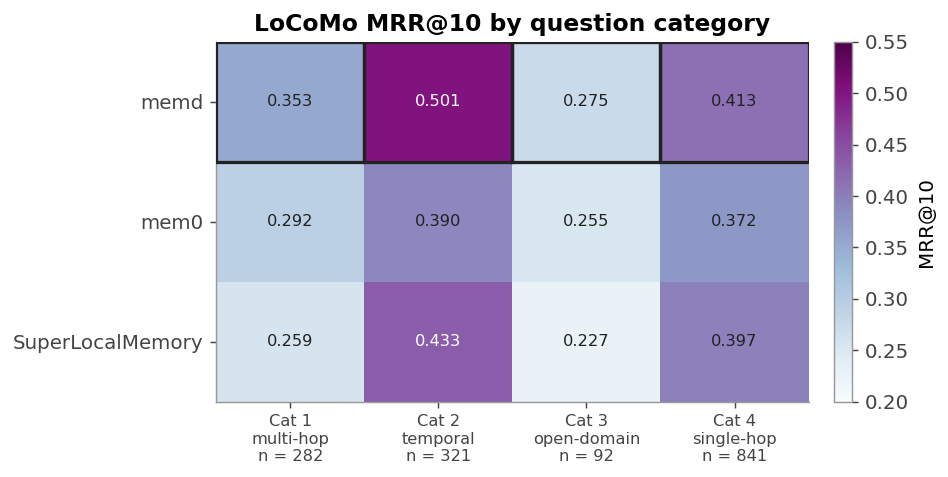

In [4]:
from matplotlib.patches import Rectangle
cats = sorted({c for s in systems for c in s['per_category']}, key=int)
matrix = np.array([[s['per_category'].get(c, {}).get('mrr_at_10', np.nan) for c in cats]
                   for s in systems])
cat_n = {c: systems[0]['per_category'].get(c, {}).get('questions') for c in cats}
fig, ax = plt.subplots(figsize=(7.4, 3.8))
im = ax.imshow(matrix, cmap='BuPu', aspect='auto', vmin=0.2, vmax=0.55)
ax.set_xticks(range(len(cats)))
ax.set_xticklabels([f'Cat {c}\n{LOCOMO_CATEGORY.get(c, "?")}\nn = {cat_n[c]}'
                    for c in cats], fontsize=9)
ax.set_yticks(range(len(systems)))
ax.set_yticklabels([s['display'] for s in systems])
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9,
                color='white' if v > 0.42 else '#222222')
# Outline the best system per category (column).
for j in range(matrix.shape[1]):
    i_best = int(np.nanargmax(matrix[:, j]))
    ax.add_patch(Rectangle((j - 0.5, i_best - 0.5), 1, 1, fill=False,
                           edgecolor='#222222', linewidth=1.8, zorder=4))
ax.set_title('LoCoMo MRR@10 by question category')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('MRR@10')
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / 'locomo_per_category.png')
fig.savefig(FIG / 'locomo_per_category.svg')
plt.show()